In [1]:
import pandas as pd
import seaborn as sns

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [2]:
train_df.shape

(120000, 3)

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [4]:
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
train_df.isnull().sum()

Class Index    0
Title          0
Description    0
dtype: int64

In [6]:
train_df["Class Index"].value_counts()

Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

<Axes: xlabel='Class Index', ylabel='count'>

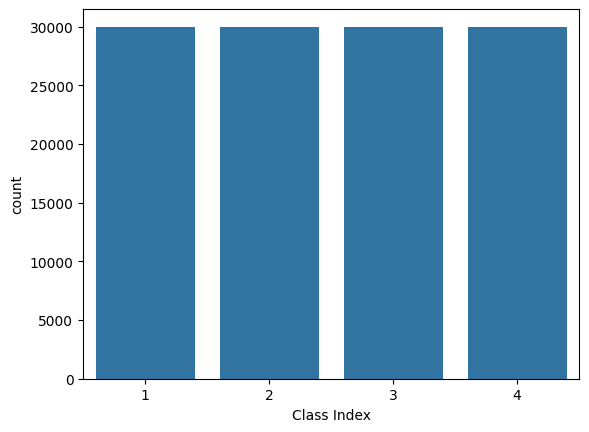

In [7]:
sns.countplot(x="Class Index", data=train_df)

In [8]:
train_df["text"] = (
    train_df["Title"].astype(str) + " " +
    train_df["Description"].astype(str)
)

In [9]:
train_df["length"] = train_df["text"].apply(len)
train_df["length"].describe()

count    120000.000000
mean        236.460025
std          66.529799
min          17.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: length, dtype: float64

In [10]:
train_df["length"].quantile([0.5, 0.9, 0.95, 0.99])

0.50    232.0
0.90    300.0
0.95    343.0
0.99    464.0
Name: length, dtype: float64

<Axes: xlabel='length', ylabel='Count'>

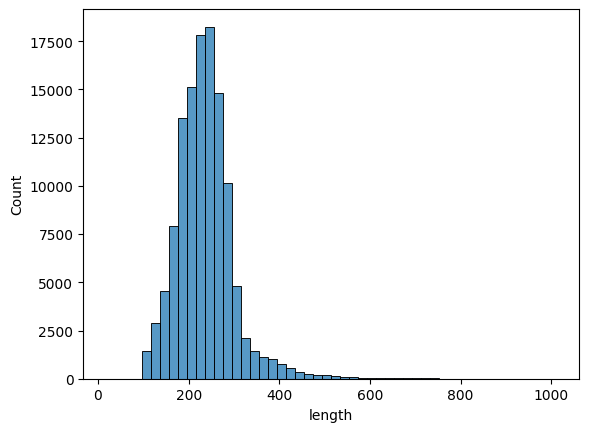

In [11]:
sns.histplot(train_df["length"], bins=50)

In [12]:
train_df.groupby("Class Index")["length"].mean()

Class Index
1    242.611533
2    224.610733
3    241.408567
4    237.209267
Name: length, dtype: float64

In [13]:
train_df["text"].duplicated().sum()

np.int64(0)